In [28]:
# pip install statsmodels

In [29]:
# pip install seaborn

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

# Dataset

In [31]:
df = pd.read_csv('https://raw.githubusercontent.com/eduardofc/data/main/boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [32]:
df.dtypes
df.shape
df.isna().sum()
df.duplicated().sum()
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,target
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


# Plots

## Unidimensionales

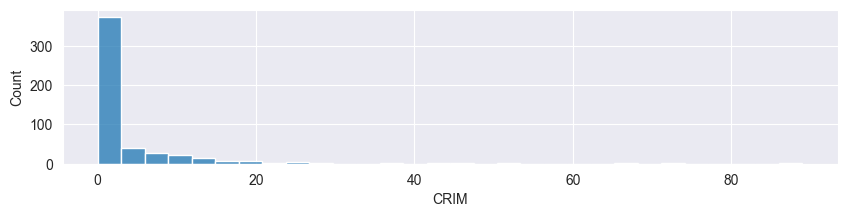

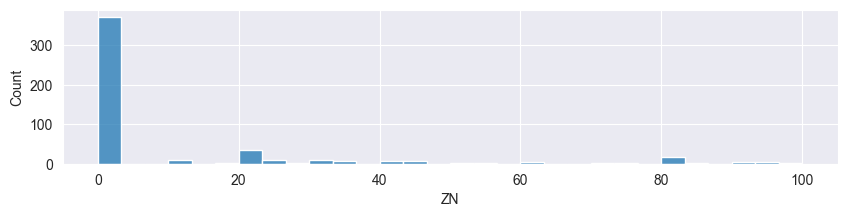

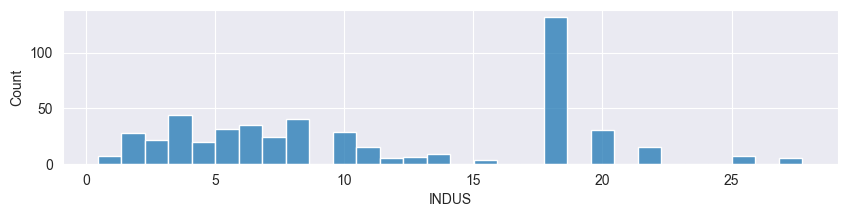

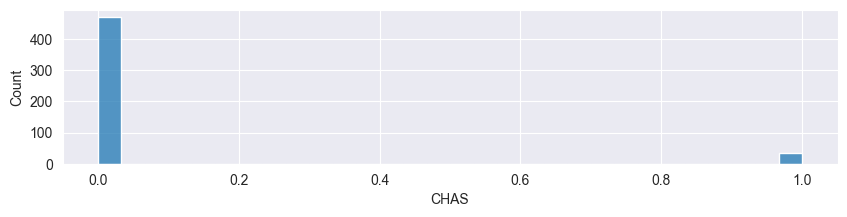

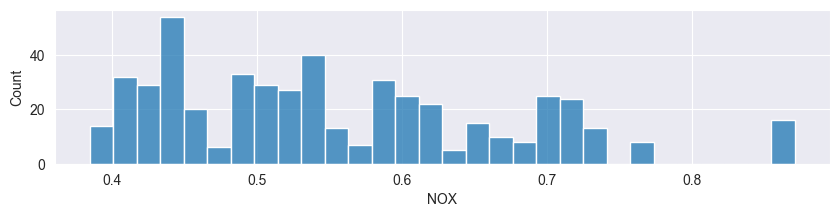

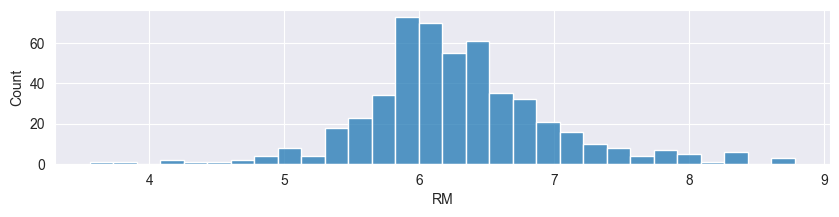

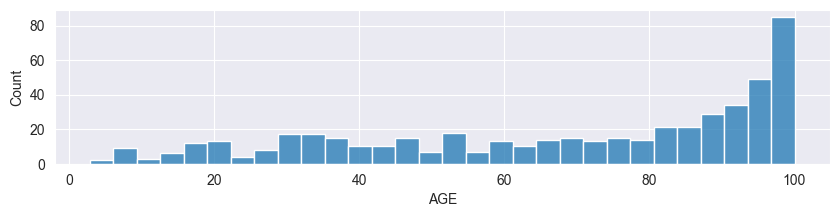

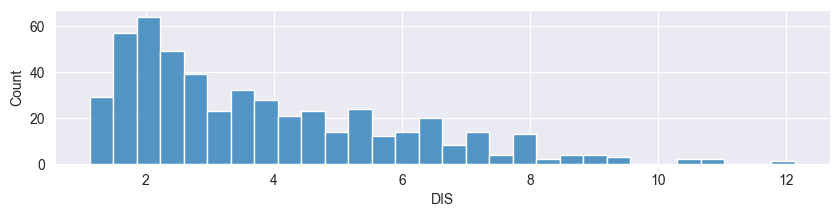

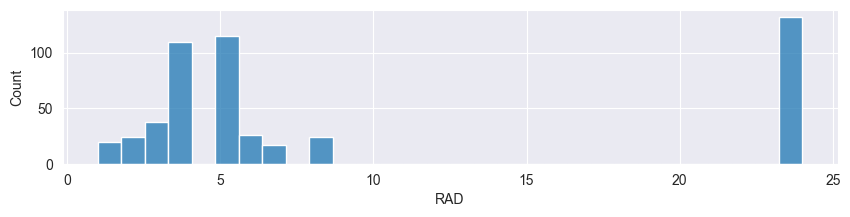

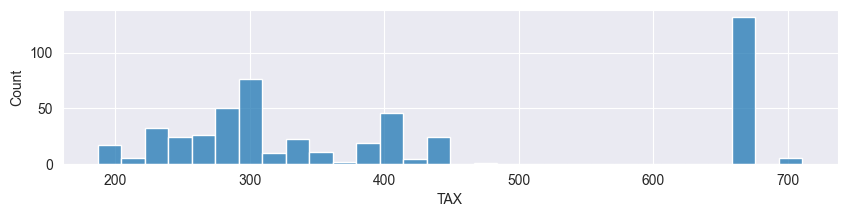

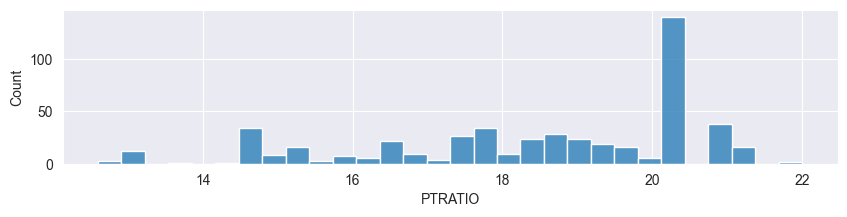

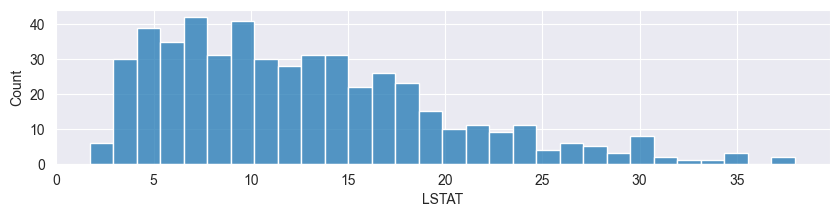

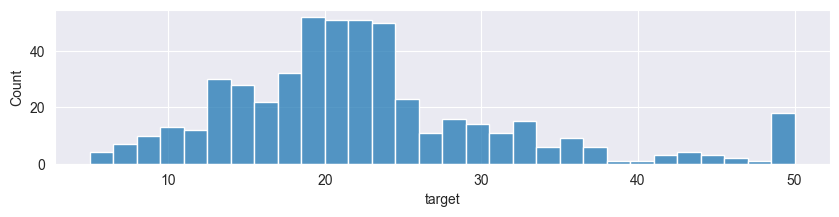

In [33]:
for col in df.columns:
    plt.figure(figsize=(10,2))
    # sns.histplot(data=df, x=col)
    # sns.histplot(data=df, x=col, bins=20, kde=True)
    sns.histplot(data=df, x=col, bins=30)
    plt.show()

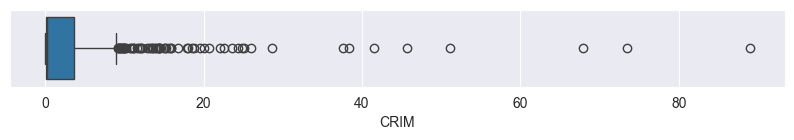

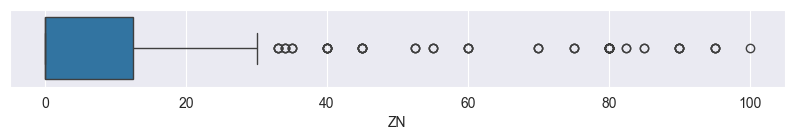

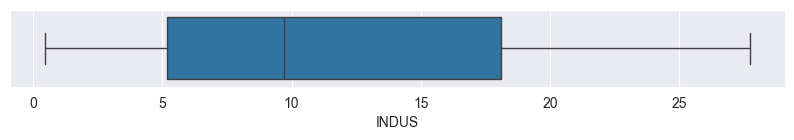

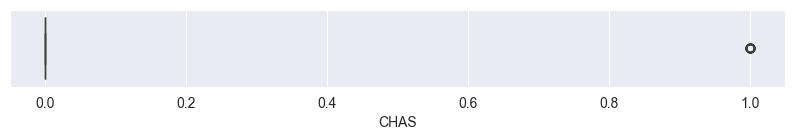

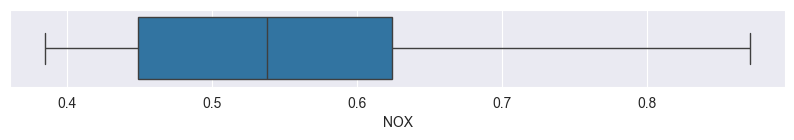

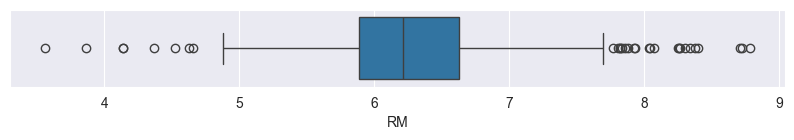

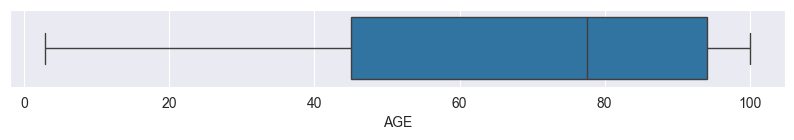

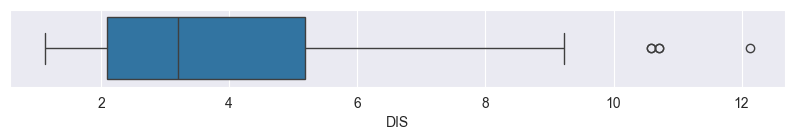

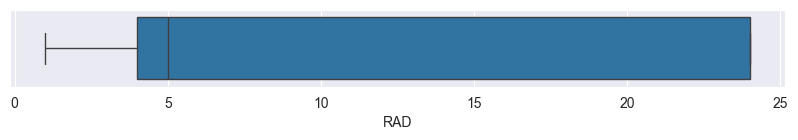

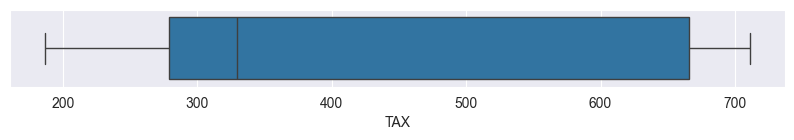

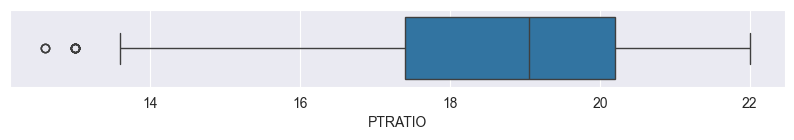

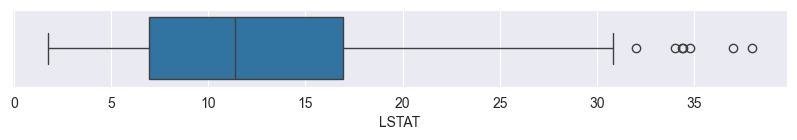

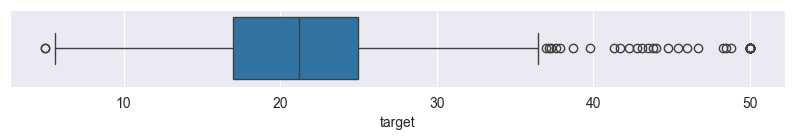

In [34]:
for col in df.columns:
    plt.figure(figsize=(10,1))
    sns.boxplot(data=df, x=col)
    # sns.violinplot(data=df, x=col)
    plt.show()

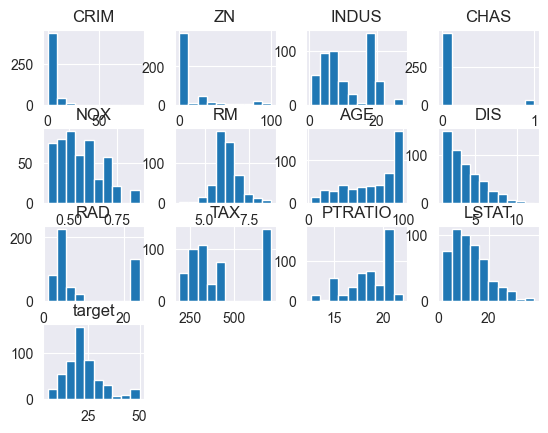

In [35]:
df.hist()
plt.show()

## Bidimensionales

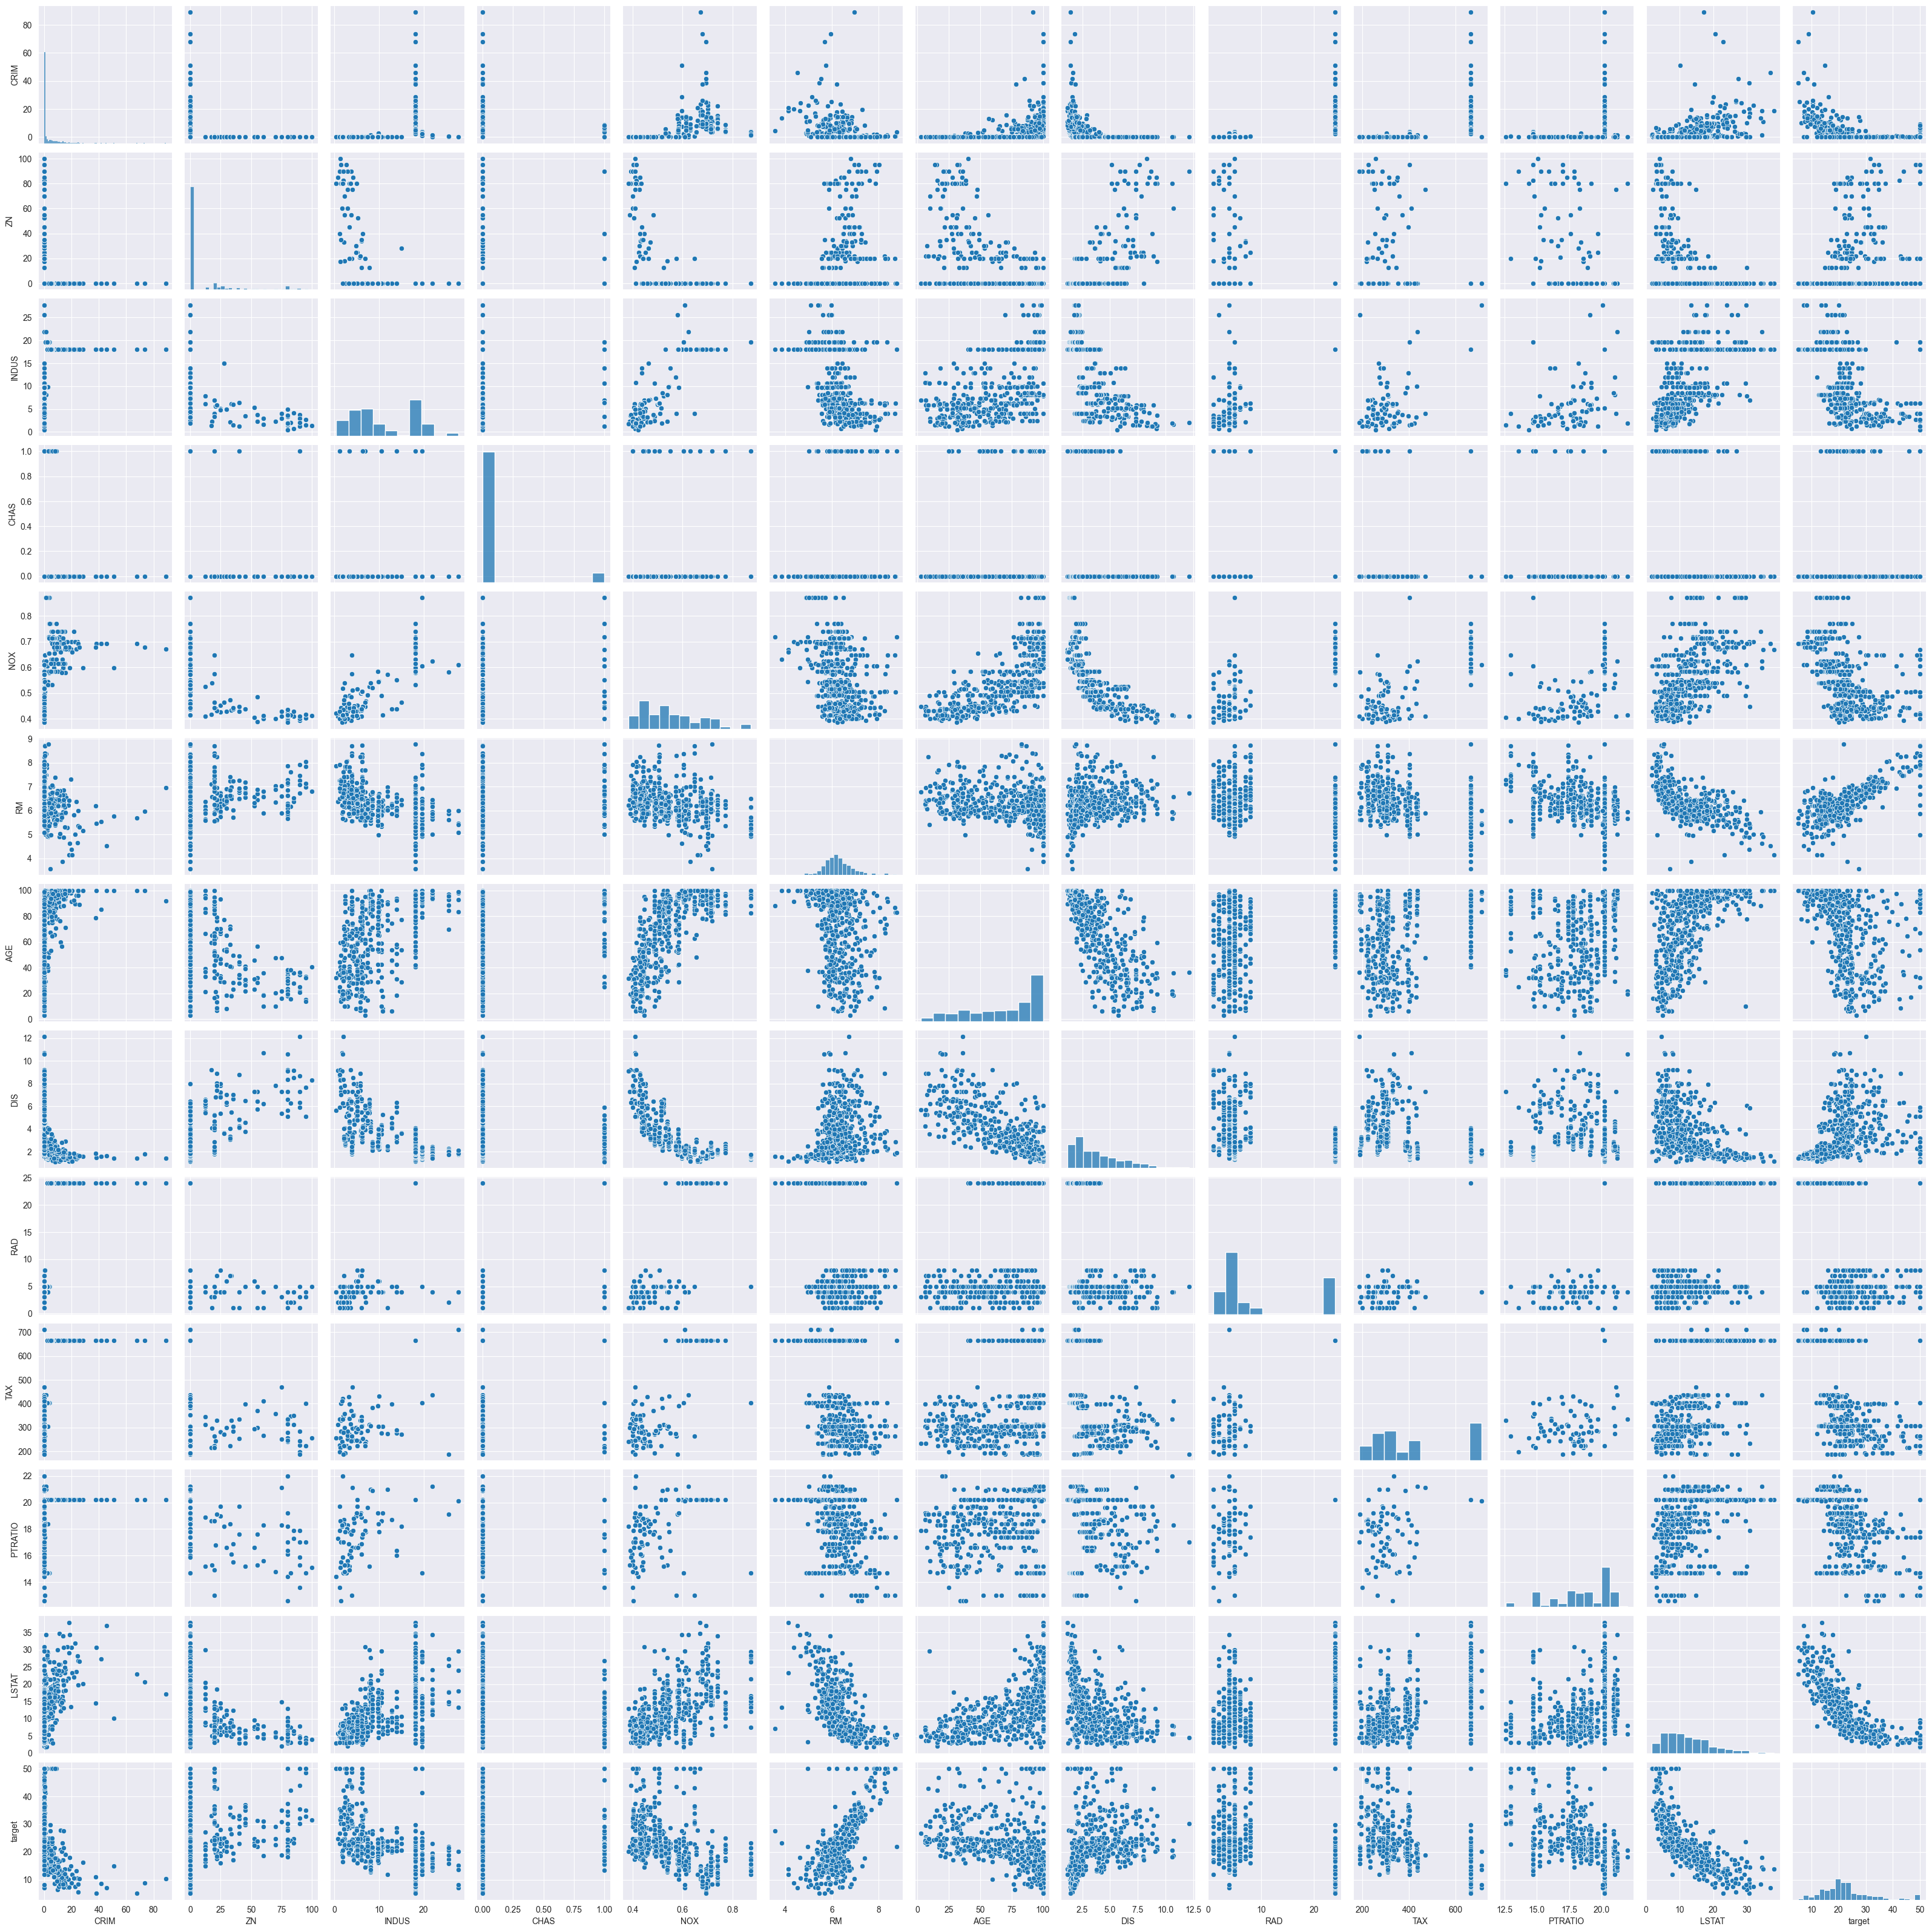

In [36]:
sns.pairplot(data=df)
plt.show()

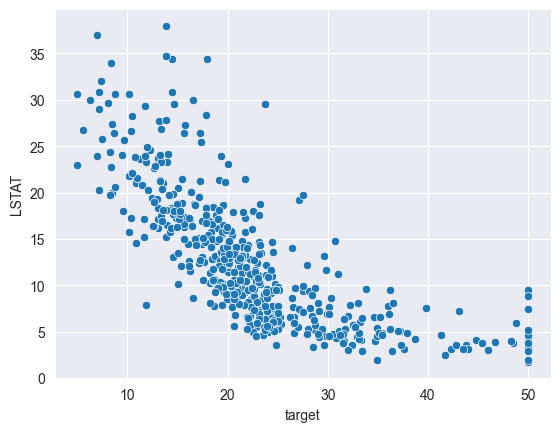

In [37]:
sns.scatterplot(data=df, x='target', y='LSTAT')
plt.show()

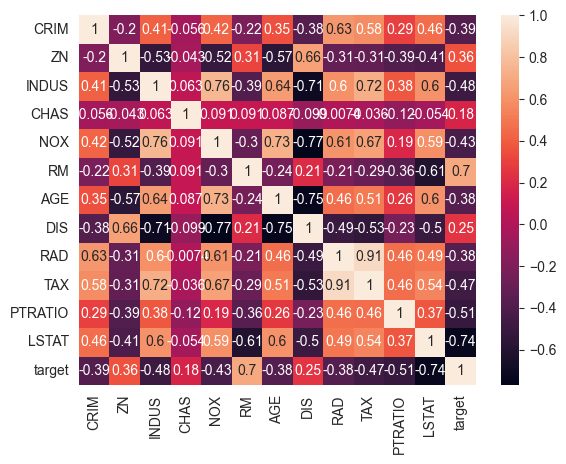

In [38]:
sns.heatmap(df.corr(), annot=True)
plt.show()

# Regresión simple

In [39]:
import statsmodels.api as sm
from statsmodels.api import OLS

In [40]:
y = df[['target']]
X = df[['LSTAT']]
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sat, 16 May 2026   Prob (F-statistic):           5.08e-88
Time:                        14:13:20   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.5538      0.563     61.415      0.000      33.448      35.659
LSTAT         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Regresión múltiple

In [41]:
y = df[['target']]
X = df.drop(columns=['target', 'INDUS', 'AGE'])
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     136.8
Date:                Sat, 16 May 2026   Prob (F-statistic):          1.73e-135
Time:                        14:13:20   Log-Likelihood:                -1505.0
No. Observations:                 506   AIC:                             3032.
Df Residuals:                     495   BIC:                             3078.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.4517      4.903      8.454      0.000      31.818      51.086
CRIM          -0.1217      0.033     -3.696      0.000      -0.186      -0.057
ZN             0.0462      0.014      3.378      0.001       0.019       0.073
CHAS           2.8719      0.863      3.329      0.001       1.177       4.567
NOX          -18.2624      3.565     -5.122      0.000     -25.267     -11.258
RM             3.6730      0.409      8.978      0.000       2.869       4.477
DIS           -1.5160      0.188     -8.078      0.000      -1.885      -1.147
RAD            0.2839      0.064      4.440      0.000       0.158       0.410
TAX           -0.0123      0.003     -3.608      0.000      -0.019      -0.006
PTRATIO       -0.9310      0.130     -7.138      0.000      -1.187      -0.675
LSTAT         -0.5465      0.047    -11.519      0.000      -0.640      -0.453
==============================================================================
Omnibus:                      172.594   Durbin-Watson:                   1.074
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              725.971
Skew:                           1.486   Prob(JB):                    2.28e-158
Kurtosis:                       8.060   Cond. No.                     1.13e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Residuos

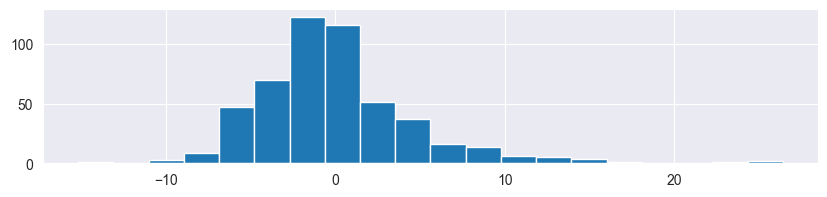

In [42]:
plt.figure(figsize=(10,2))
plt.hist(model.resid, bins=20)
plt.show()

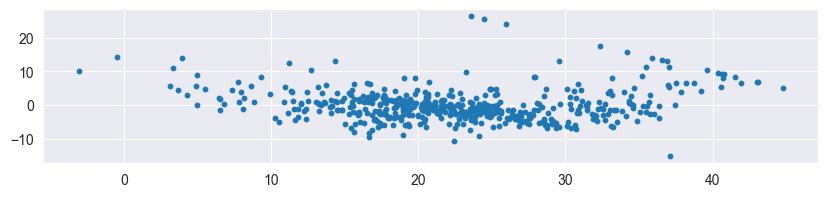

In [43]:
plt.figure(figsize=(10,2))
plt.scatter(model.fittedvalues, model.resid, s=10)
plt.show()

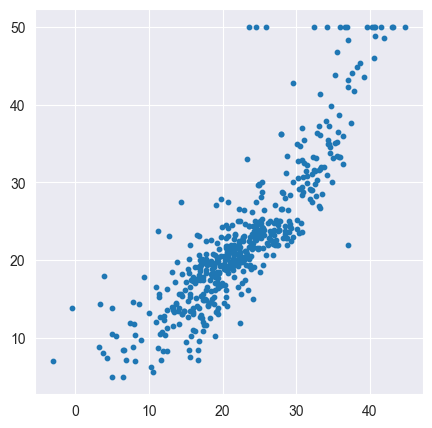

In [44]:
plt.figure(figsize=(5,5))
plt.scatter(model.fittedvalues, y, s=10)
plt.show()

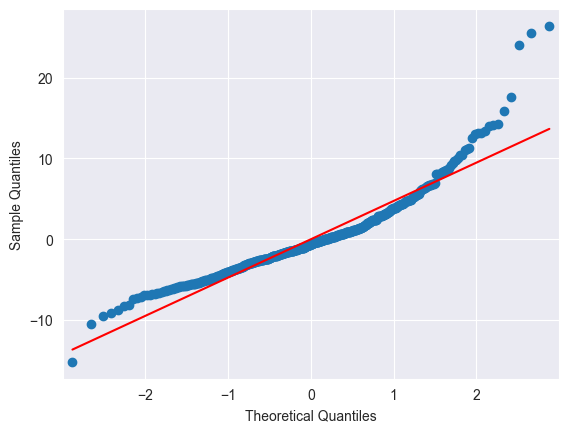

In [45]:
# qqplot

sm.qqplot(model.resid, line='s')
plt.show()

# Multicolinealidad

In [46]:
y = df[['target']]
X = df.drop(columns=['target', 'INDUS', 'AGE', 'TAX', 'NOX', 'RAD'])
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     171.5
Date:                Sat, 16 May 2026   Prob (F-statistic):          2.78e-128
Time:                        14:13:20   Log-Likelihood:                -1529.9
No. Observations:                 506   AIC:                             3076.
Df Residuals:                     498   BIC:                             3110.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.9230      4.024      5.449      0.000      14.018      29.829
CRIM          -0.1019      0.031     -3.331      0.001      -0.162      -0.042
ZN             0.0418      0.014      3.002      0.003       0.014       0.069
CHAS           2.8331      0.898      3.156      0.002       1.069       4.597
RM             4.0965      0.420      9.750      0.000       3.271       4.922
DIS           -0.8549      0.161     -5.311      0.000      -1.171      -0.539
PTRATIO       -0.7760      0.121     -6.429      0.000      -1.013      -0.539
LSTAT         -0.6222      0.048    -13.070      0.000      -0.716      -0.529
==============================================================================
Omnibus:                      160.468   Durbin-Watson:                   1.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              652.532
Skew:                           1.383   Prob(JB):                    2.02e-142
Kurtosis:                       7.827   Cond. No.                         531.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for ii, col in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, ii)
    print(f"{col}: {vif:.2f}")

const: 325.68
CRIM: 1.39
ZN: 2.12
CHAS: 1.04
RM: 1.75
DIS: 2.31
PTRATIO: 1.37
LSTAT: 2.32


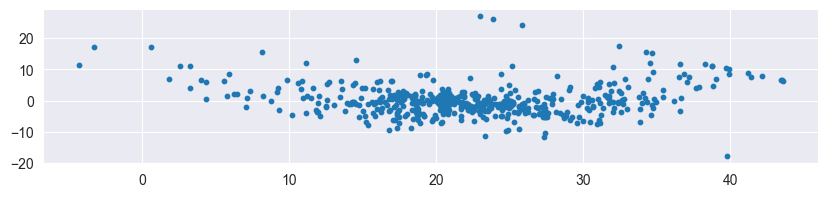

In [48]:
plt.figure(figsize=(10,2))
plt.scatter(model.fittedvalues, model.resid, s=10)
plt.show()

# AIC / BIC

In [49]:
key_columns = ['CRIM', 'ZN', 'CHAS', 'RM', 'DIS', 'PTRATIO', 'LSTAT']

# for col in key_columns:
#     y = df[['target']]
#     X = df.drop(columns=['target', 'INDUS', 'AGE', 'TAX', 'NOX', 'RAD', col])
#     X = sm.add_constant(X)
#     model = OLS(y, X).fit()
    
#     print(f"{col} -> {model.aic:.2f} | {model.bic:.2f} | {model.rsquared:.3f}")

# Normalizar

## Min Max

In [50]:
df2 = df[key_columns].copy()

for col in df2.columns:
    col_min = df2[col].min()
    col_max = df2[col].max()
    df2[col] = (df2[col] - col_min) / (col_max - col_min)

df2.head()

,CRIM,ZN,CHAS,RM,DIS,PTRATIO,LSTAT
0,0.000000,0.18,0.0,0.577505,0.269203,0.287234,0.089680
1,0.000236,0.00,0.0,0.547998,0.348962,0.553191,0.204470
2,0.000236,0.00,0.0,0.694386,0.348962,0.553191,0.063466
3,0.000293,0.00,0.0,0.658555,0.448545,0.648936,0.033389
4,0.000705,0.00,0.0,0.687105,0.448545,0.648936,0.099338


In [51]:
y = df[['target']]
X = df2.copy()
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     171.5
Date:                Sat, 16 May 2026   Prob (F-statistic):          2.78e-128
Time:                        14:13:21   Log-Likelihood:                -1529.9
No. Observations:                 506   AIC:                             3076.
Df Residuals:                     498   BIC:                             3110.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.6905      1.814     13.609      0.000      21.126      28.255
CRIM          -9.0666      2.722     -3.331      0.001     -14.414      -3.719
ZN             4.1812      1.393      3.002      0.003       1.445       6.917
CHAS           2.8331      0.898      3.156      0.002       1.069       4.597
RM            21.3798      2.193      9.750      0.000      17.071      25.688
DIS           -9.4013      1.770     -5.311      0.000     -12.879      -5.923
PTRATIO       -7.2944      1.135     -6.429      0.000      -9.524      -5.065
LSTAT        -22.5477      1.725    -13.070      0.000     -25.937     -19.158
==============================================================================
Omnibus:                      160.468   Durbin-Watson:                   1.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              652.532
Skew:                           1.383   Prob(JB):                    2.02e-142
Kurtosis:                       7.827   Cond. No.                         19.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Standarizer

In [52]:
df3 = df[key_columns].copy()

for col in df3.columns:
    col_mean = df3[col].mean()
    col_std = df3[col].std()
    df3[col] = (df3[col] - col_mean) / col_std

df3.head()

,CRIM,ZN,CHAS,RM,DIS,PTRATIO,LSTAT
0,-0.419367,0.284548,-0.272329,0.413263,0.140075,-1.457558,-1.074499
1,-0.416927,-0.487240,-0.272329,0.194082,0.556609,-0.302794,-0.491953
2,-0.416929,-0.487240,-0.272329,1.281446,0.556609,-0.302794,-1.207532
3,-0.416338,-0.487240,-0.272329,1.015298,1.076671,0.112920,-1.360171
4,-0.412074,-0.487240,-0.272329,1.227362,1.076671,0.112920,-1.025487


In [53]:
y = df[['target']]
X = df3.copy()
X = sm.add_constant(X)

model = OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 target   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     171.5
Date:                Sat, 16 May 2026   Prob (F-statistic):          2.78e-128
Time:                        14:13:21   Log-Likelihood:                -1529.9
No. Observations:                 506   AIC:                             3076.
Df Residuals:                     498   BIC:                             3110.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5328      0.223    101.062      0.000      22.095      22.971
CRIM          -0.8765      0.263     -3.331      0.001      -1.394      -0.360
ZN             0.9751      0.325      3.002      0.003       0.337       1.613
CHAS           0.7196      0.228      3.156      0.002       0.272       1.168
RM             2.8783      0.295      9.750      0.000       2.298       3.458
DIS           -1.8002      0.339     -5.311      0.000      -2.466      -1.134
PTRATIO       -1.6800      0.261     -6.429      0.000      -2.193      -1.167
LSTAT         -4.4430      0.340    -13.070      0.000      -5.111      -3.775
==============================================================================
Omnibus:                      160.468   Durbin-Watson:                   1.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              652.532
Skew:                           1.383   Prob(JB):                    2.02e-142
Kurtosis:                       7.827   Cond. No.                         3.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [54]:
# comentar la posibilidad de usar el logartimo en X='crim' para cambiar la distribución